## Loading the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("top_anime_dataset.csv")

In [ ]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,62148,2.0,644,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
3,57555,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,Movie,Manga,1.0,Finished Airing,False,R - 17+ (violence & profanity),9.09,255607,4.0,643,414906,12097,Despite the immediate challenges following bec...,NaN,"Action, Fantasy",MAPPA,https://myanimelist.net/anime/57555/Chainsaw_M...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate


In [ ]:
df.shape

(500, 20)

In [ ]:
df.columns

Index(['mal_id', 'title', 'title_english', 'type', 'source', 'episodes',
       'status', 'airing', 'rating', 'score', 'scored_by', 'rank',
       'popularity', 'members', 'favorites', 'synopsis', 'year', 'genres',
       'studios', 'url'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         500 non-null    int64  
 1   title          500 non-null    object 
 2   title_english  458 non-null    object 
 3   type           500 non-null    object 
 4   source         500 non-null    object 
 5   episodes       492 non-null    float64
 6   status         500 non-null    object 
 7   airing         500 non-null    bool   
 8   rating         500 non-null    object 
 9   score          500 non-null    float64
 10  scored_by      500 non-null    int64  
 11  rank           492 non-null    float64
 12  popularity     500 non-null    int64  
 13  members        500 non-null    int64  
 14  favorites      500 non-null    int64  
 15  synopsis       500 non-null    object 
 16  year           297 non-null    float64
 17  genres         494 non-null    object 
 18  studios   

## Cleaning the data

#### Missing values

In [ ]:
df.isnull().sum()

,0
mal_id,0
title,0
title_english,42
type,0
source,0
episodes,8
status,0
airing,0
rating,0
score,0


In [ ]:
df['title_english'] = df['title_english'].fillna(df['title'])

In [ ]:
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

In [ ]:
df['rank'] = df['rank'].fillna(df['rank'].median())

In [ ]:
df['year'] = df['year'].fillna('Unknown')

In [ ]:
df['studios'] = df['studios'].fillna('Unknown')

In [ ]:
df['genres'] = df['genres'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
mal_id,0
title,0
title_english,0
type,0
source,0
episodes,0
status,0
airing,0
rating,0
score,0


- Missing values in title_english were replaced with the original title.
- Missing values in numerical columns episodes and rank were filled using the median.
- The year column had many missing values, so these were labeled as 'Unknown'.
- Missing values in studio were filled with 'Unknown'.
- Missing values in genres were filled with 'Unknown'.

#### Dropping columns that are not needed

- These include:
  - mal_id
  - synopsis
  - url

In [ ]:
df.columns

Index(['mal_id', 'title', 'title_english', 'type', 'source', 'episodes',
       'status', 'airing', 'rating', 'score', 'scored_by', 'rank',
       'popularity', 'members', 'favorites', 'synopsis', 'year', 'genres',
       'studios', 'url'],
      dtype='object')

In [ ]:
df = df.drop(columns = ['mal_id', 'synopsis', 'url'])

In [ ]:
df.columns

Index(['title', 'title_english', 'type', 'source', 'episodes', 'status',
       'airing', 'rating', 'score', 'scored_by', 'rank', 'popularity',
       'members', 'favorites', 'year', 'genres', 'studios'],
      dtype='object')

#### Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics for Numerical Columns

In [ ]:
df.describe()

,episodes,score,scored_by,rank,popularity,members,favorites
count,500.000000,500.000000,5.000000e+02,500.000000,500.000000,5.000000e+02,500.000000
mean,18.256000,8.428940,3.271719e+05,246.552000,1559.430000,5.789175e+05,13815.252000
std,35.142003,0.222604,4.517006e+05,141.073182,1919.380637,6.924760e+05,29497.765969
min,1.000000,8.160000,9.190000e+02,1.000000,1.000000,2.212000e+03,24.000000
25%,1.000000,8.250000,4.857050e+04,125.750000,294.750000,1.133312e+05,852.000000
50%,12.000000,8.370000,1.519620e+05,246.500000,839.500000,3.296165e+05,3453.500000
75%,24.000000,8.562500,4.098580e+05,367.250000,2174.250000,7.721738e+05,13553.750000
max,500.000000,9.280000,3.038808e+06,494.000000,12270.000000,4.316356e+06,249284.000000


## Visualization

#### Distribution of Anime Scores

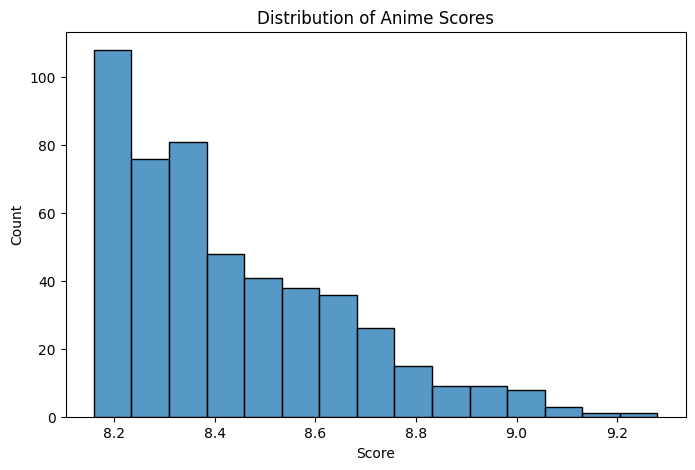

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['score'])

plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Count')

plt.savefig('Histogram_DistributionOfAnimeScores')
plt.show()

- The histogram shows that most anime scores fall between 8.0 and 8.6, indicating that the dataset contains predominantly highly rated anime. Only a small number of anime achieve scores above 9.0, suggesting that extremely high ratings are relatively rare.

#### Distribution of Anime Types

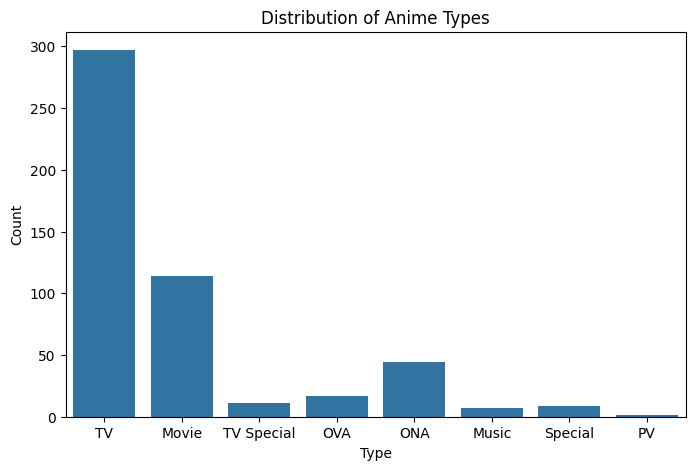

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type')

plt.title('Distribution of Anime Types')
plt.xlabel('Type')
plt.ylabel('Count')

plt.savefig('Countplot_AnimeTypes')
plt.show()

- The distribution of anime types shows that TV series are the most common format in the dataset. Movies and specials also appear frequently, while promotional videos (PV) represent the smallest portion. This suggests that TV anime make up the majority of highly ranked anime productions.

#### Score by Anime Type

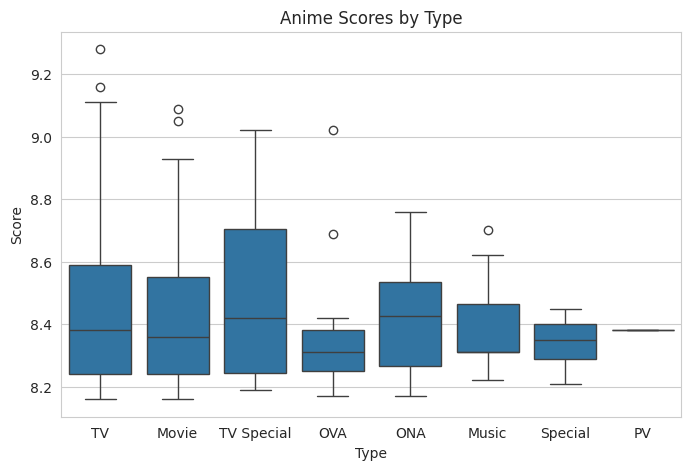

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="type", y="score")

plt.title("Anime Scores by Type")
plt.xlabel("Type")
plt.ylabel("Score")

plt.show()

#### Episodes vs Score

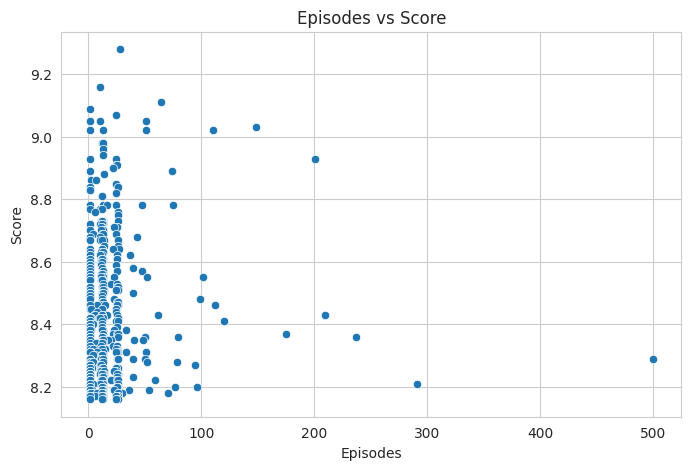

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="episodes", y="score")

plt.title("Episodes vs Score")
plt.xlabel("Episodes")
plt.ylabel("Score")

plt.show()

#### Popularity vs Score

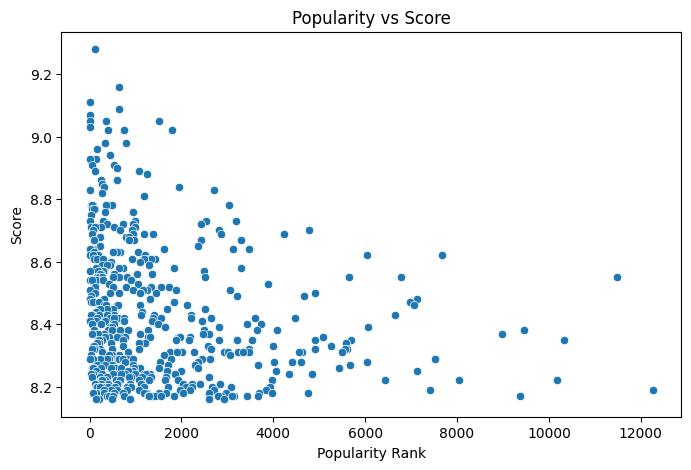

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="popularity", y="score")

plt.title("Popularity vs Score")
plt.xlabel("Popularity Rank")
plt.ylabel("Score")

plt.savefig("Scatterplot_PopularityVsScore")
plt.show()

#### Correlation Heatmap

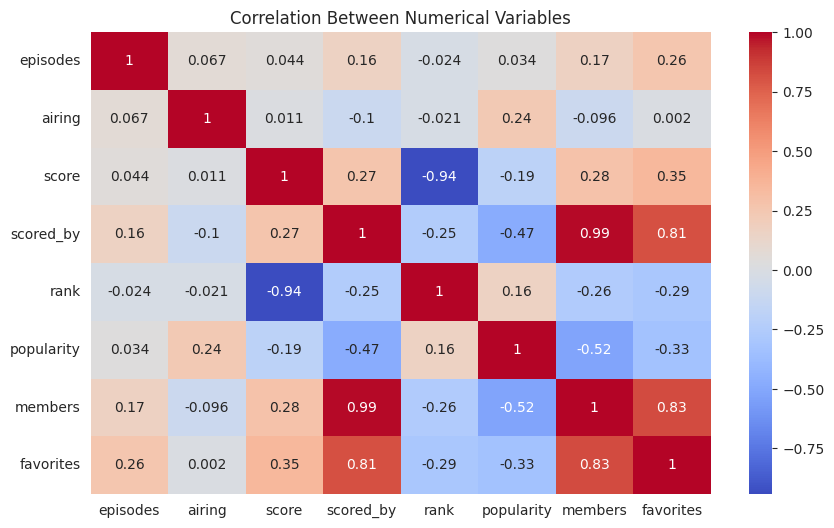

In [ ]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Numerical Variables")

plt.show()

#### Top 10 Most Popular Anime

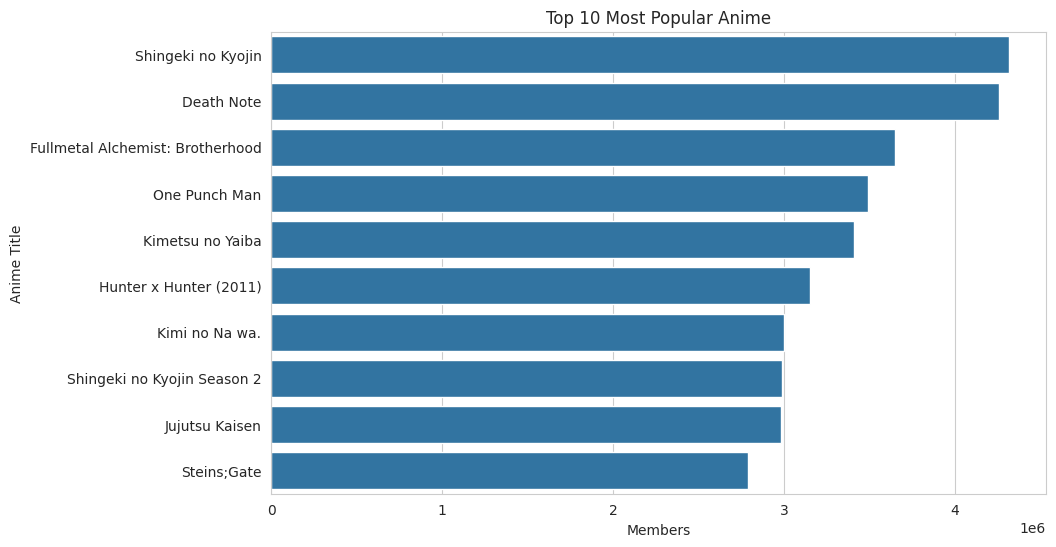

In [ ]:
top_popular = df.sort_values(by="members", ascending=False).head(10)

top_popular[['title','members']]

plt.figure(figsize=(10,6))

sns.barplot(data=top_popular, x="members", y="title")

plt.title("Top 10 Most Popular Anime")
plt.xlabel("Members")
plt.ylabel("Anime Title")

plt.show()

#### Most Common Genres

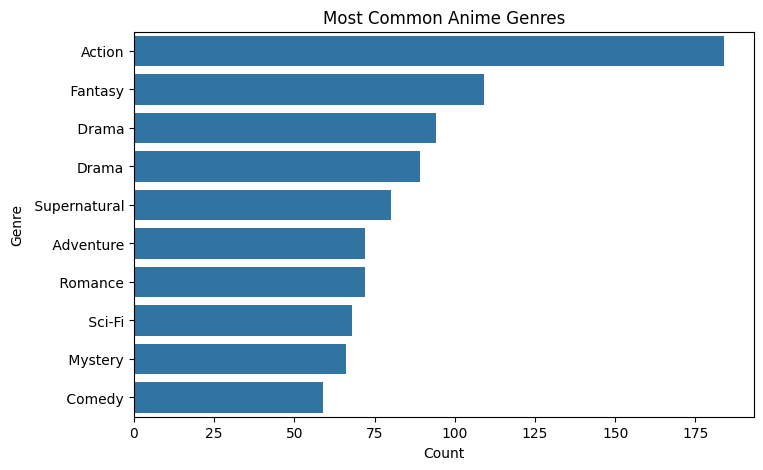

In [ ]:
genres = df['genres'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Most Common Anime Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.savefig('Barplot_GenreDistribution')
plt.show()

- The genre analysis shows that Action is the most common genre among the top anime, while Comedy appears the least frequently. Action is a very dominant genre in anime because many popular shows involve battles and fighting scenes between characters. Comedy-only anime appear less often in top-ranked lists.This indicates that action-oriented anime tend to dominate popularity and rankings within the dataset.

#### Score by Genre

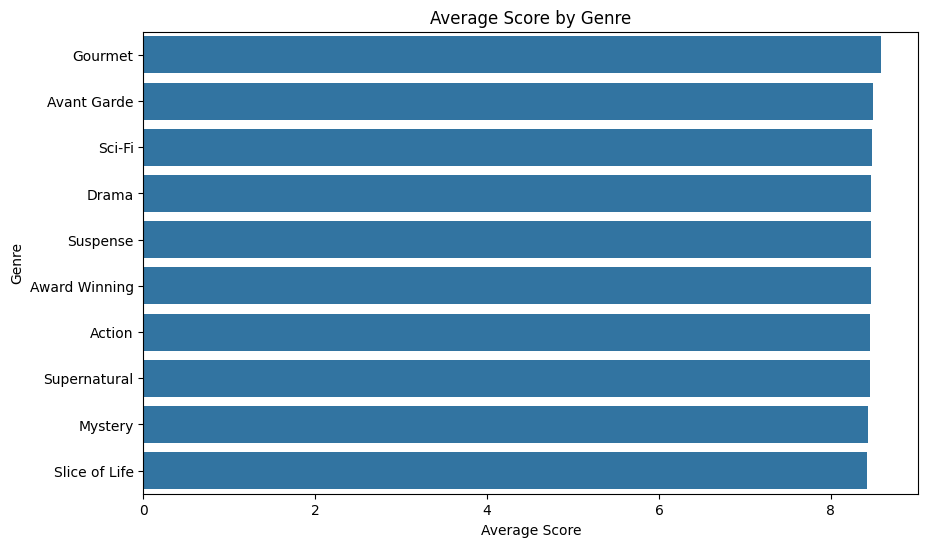

In [ ]:
genres_score = df[['genres','score']].copy()

genres_score['genres'] = genres_score['genres'].str.split(',')

genres_score = genres_score.explode('genres')

genres_score['genres'] = genres_score['genres'].str.strip()

top_genre_scores = genres_score.groupby('genres')['score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genre_scores.values, y=top_genre_scores.index)

plt.title("Average Score by Genre")
plt.xlabel("Average Score")
plt.ylabel("Genre")

plt.savefig('Barplot_AverageScoreByGenre')
plt.show()

- The average scores across genres appear very close to one another. This suggests that genre alone may not strongly influence anime ratings. Instead, other factors such as storytelling quality, animation, or studio production may play a larger role in determining audience scores.

#### Number of Top Anime Released Per Year

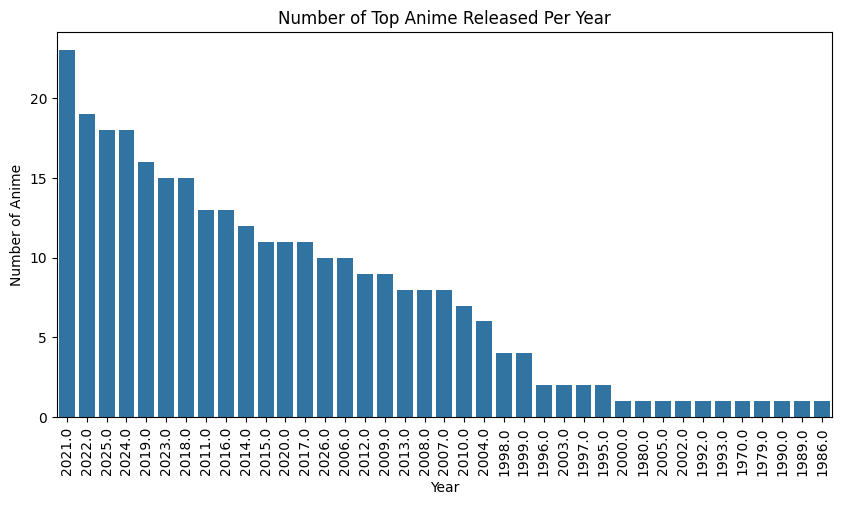

In [ ]:
year_df = df[df['year'] != "Unknown"]

plt.figure(figsize=(10,5))

sns.countplot(data=year_df, x="year", order=year_df['year'].value_counts().index)

plt.xticks(rotation=90)

plt.title("Number of Top Anime Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Anime")

plt.savefig('Countplot_AnimePerYear')
plt.show()

- A large number of entries had missing values for the year column and were labeled as "Unknown" during data cleaning. Since these values do not represent actual release years, they were excluded from the year-based analysis to ensure accurate visualization of anime releases over time.

- From above, we see that 2021 produced the largest number of top ranking anime

## Hypotheses

#### Hypothesis Test 1
#### Do TV anime have higher scores than Movies?

- Research Question
  - Is there a significant difference between the scores of TV anime and Movies?

- Null Hypothesis (H₀)
  - There is no significant difference between the average scores of TV anime and Movies.

- Alternative Hypothesis (H₁)
  - There is a significant difference between the average scores of TV anime and Movies.
	​


In [ ]:
from scipy.stats import ttest_ind

tv_scores = df[df['type'] == 'TV']['score']
movie_scores = df[df['type'] == 'Movie']['score']

t_stat, p_value = ttest_ind(tv_scores, movie_scores)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.293482283439599
P-value: 0.1965743423824763


Since the p-value is more than 0.05, we reject the alternative hypothesis and conclude that there is no statistically significant difference between the scores of TV anime and Movies.

#### Hypothesis Test 2
#### Does popularity affect anime scores?

- Research Question
  - Is there a significant relationship between anime popularity and score?

- Null Hypothesis (H₀)
  - There is no correlation between popularity and score.

- Alternative Hypothesis (H₁)
  - There is a correlation between popularity and score.

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['popularity'], df['score'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.18815159657351332
P-value: 2.2901482225096653e-05


Since the p-value is more than 0.05, we reject the alternative hypothesis and conclude that there is no correlation between popularity and score.